# Γ ramps: standard errors of the CO₂ and SAI coefficients

Thin wrapper around `gamma_model.py` / `gamma_plot.py` that reproduces the Γ-ramps figure and lets you change
parameters and plotting options.

**Model (per region):** $T_t = \Gamma_{CO_2}\ln(c_t/278.3) + \Gamma_{SAI}\,\Delta T\,(\min(t,t_{cap})/t_{ref})^z + \varepsilon_t$,
with $\varepsilon_t \sim N(0,\sigma^2)$ white, $t = 1$ in 2026, and $c_t$ a CO₂ scenario starting in 2026.
Here $\Gamma_{CO_2} = \alpha f/L_{eff}$ and $\Gamma_{SAI} = \beta L_{eff} - \alpha$.

The SEs are the exact least-squares covariance $\sigma^2 (X^\top X)^{-1}$ (equal to the
Cramér–Rao bound). They **do not depend on the true α, β, f or L_eff**, which is why none of
those appear below. They do depend on σ, z, ΔT, the cap, the scenario, and the window.

Two structural facts worth knowing when you play with this:
* Doubling ΔT halves SE(Γ_SAI) and leaves SE(Γ_CO₂) unchanged. So ΔT changes only the raw SAI row,
  and has no effect on the relative-to-2030 rows.
* With several regions sharing this design, region *r*'s SEs are these curves times σ_r/σ.

No install needed: run this notebook from `conceptual/` so `gamma_model` and `gamma_plot` import directly.

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import gamma_model as gm
import gamma_plot as gp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configuration
Changing anything in this cell requires re-running the compute cell (§3). Plotting options are in §4–5.

In [ ]:
CSV = "../data/input/scenariomip7_conc_paths.csv"   # scenario statistics file
STAT = "median"                            # CSV column: mean, median, p05, p17, ..., p95
Z_VALUES = [1/3, 1, 3]                     # SAI ramp exponents
DELTA_T = [0.5, 1.0]                       # SAI amplitudes; first is drawn solid
SIGMA = 0.3                                # white-noise std
DESIGN = dict(t_ref=50.0, t_cap=50.0, modulated=True)      # SAI regressor reaches ΔT at t_ref; plateau from t_cap (None = no cap)
YEAR0 = 2025                               # t = 1 is YEAR0 + 1
FIG_DIR = Path("../analysis/figs/conceptual")   # figure/output directory
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Scenarios

['high-extension / high-overshoot', 'medium-extension', 'medium-overshoot', 'low', 'verylow', 'verylow-overshoot']


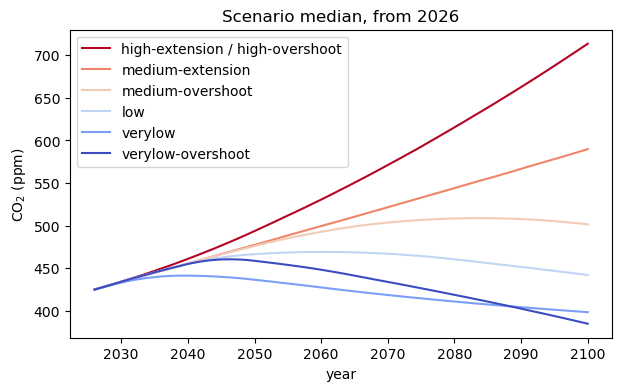

In [ ]:
scen = gm.load_scenarios(CSV, STAT, YEAR0 + 1, 2100 + (YEAR0 - 2025))
print(list(scen.columns))
ax = scen.plot(figsize=(7, 4), cmap="coolwarm_r")
ax.set_ylabel("CO$_2$ (ppm)"); ax.set_title(f"Scenario {STAT}, from {YEAR0 + 1}");

## 3. Compute the SE table
Tidy DataFrame: one row per (scenario, z, ΔT, window). `se_*_rel` divide by the first window (2030).

In [ ]:
df = gm.se_table(scen, Z_VALUES, DELTA_T, sigma=SIGMA, year0=YEAR0, **DESIGN)
df.head()

,scenario,z,delta_T,N,year,se_co2,se_sai,corr,se_co2_rel,se_sai_rel
0,high-extension / high-overshoot,0.333333,0.5,5,2030,4.237986,9.921590,-0.997332,1.000000,1.000000
1,high-extension / high-overshoot,0.333333,0.5,6,2031,1.973910,4.311157,-0.989844,0.465766,0.434523
2,high-extension / high-overshoot,0.333333,0.5,7,2032,1.284695,2.582453,-0.979605,0.303138,0.260286
3,high-extension / high-overshoot,0.333333,0.5,8,2033,1.122578,2.141041,-0.976894,0.264885,0.215796
4,high-extension / high-overshoot,0.333333,0.5,9,2034,1.109124,2.082380,-0.979254,0.261710,0.209884


## 4. Reproduce the figure

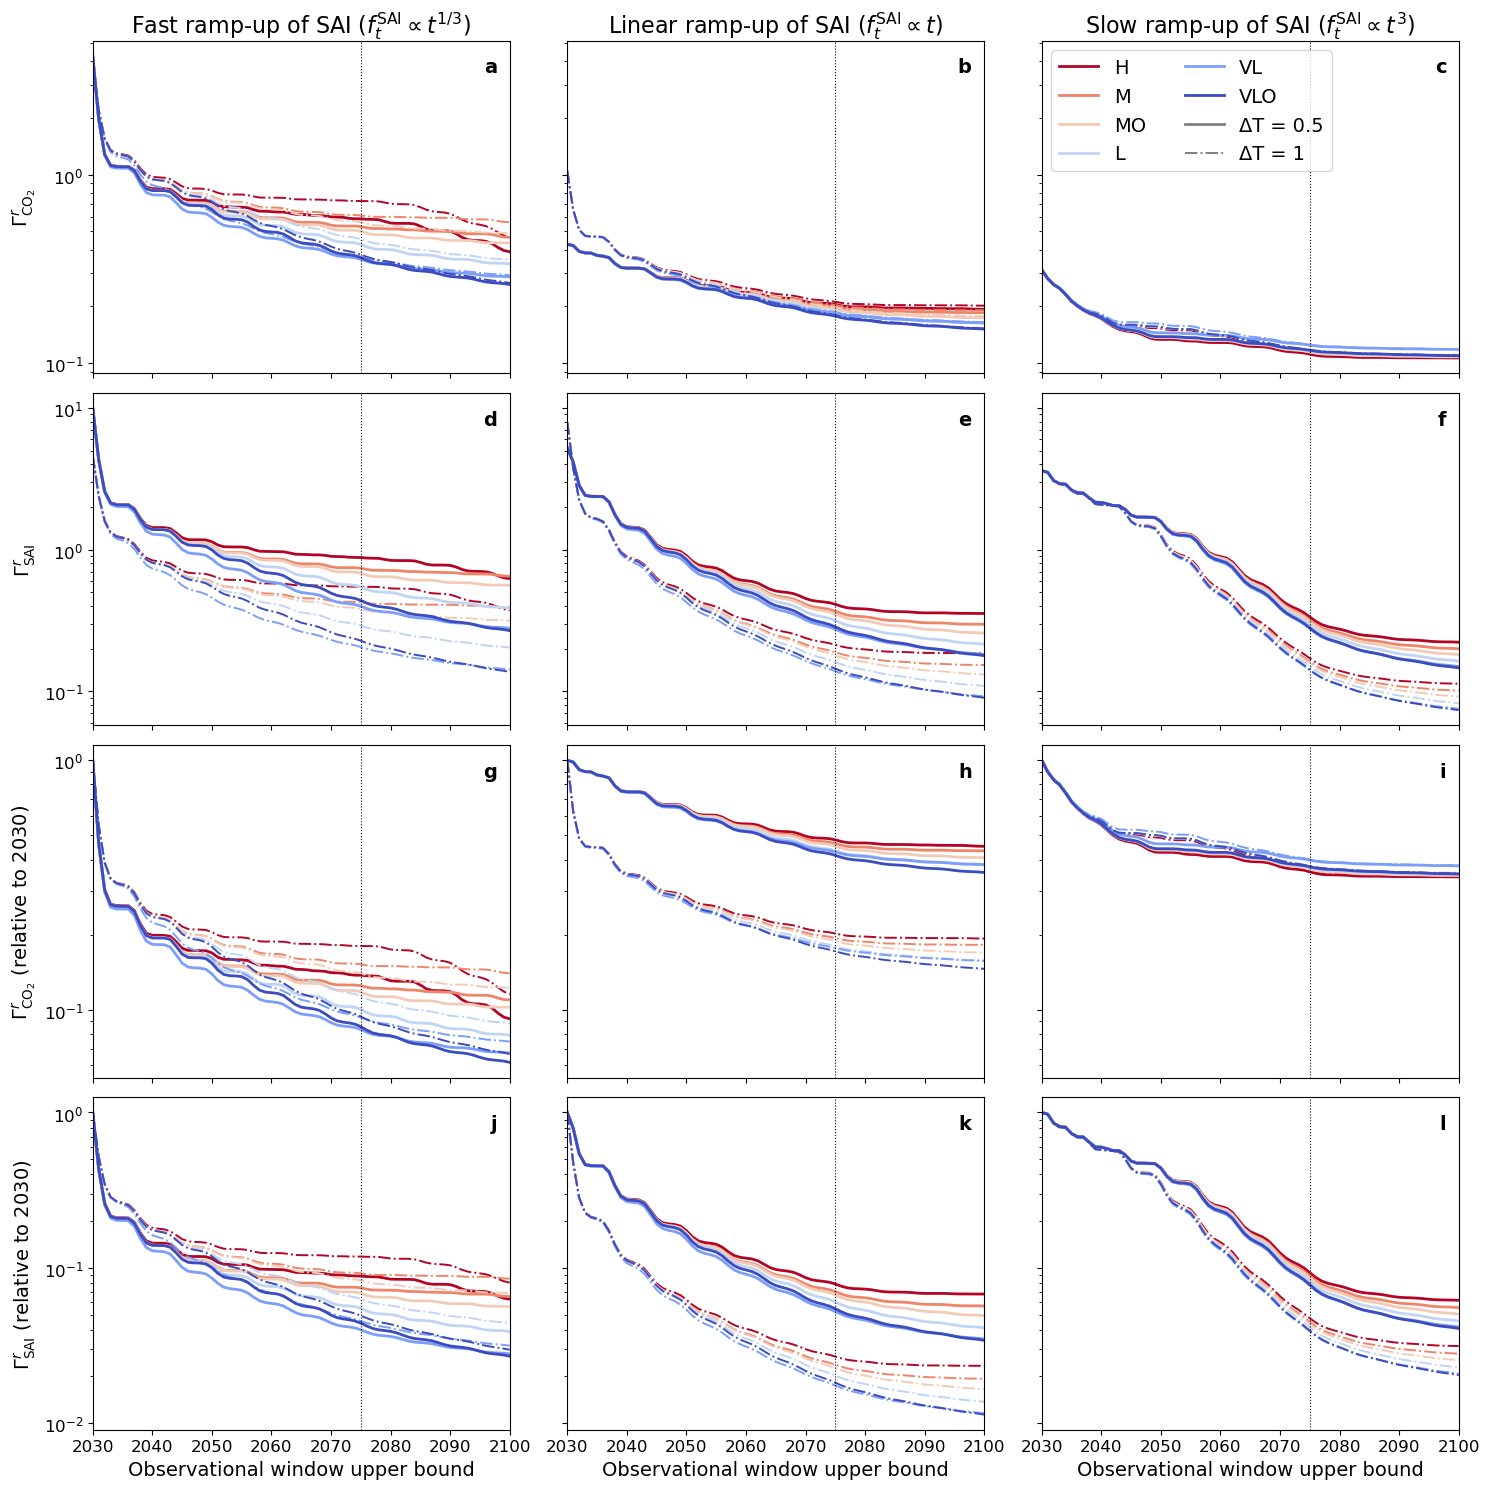

In [ ]:
fig, ax = gp.plot_se_grid(df,
                          xlim=(2080, 2150) if YEAR0 == 2075 else (2030, 2100))
fname = f'gamma_ramps_{YEAR0}.png' if not DESIGN.get('modulated') else f'gamma_ramps_{YEAR0}_spicy.png'
fig.savefig(FIG_DIR / fname, dpi=150)

## 5. Plotting knobs

`plot_se_grid(df, ...)` only draws; it never recomputes. Main options:

| argument | meaning |
|---|---|
| `columns` | list of `(z, title)`; one panel column each |
| `rows` | list of `(df column, y label)`; e.g. `"se_co2"`, `"se_sai"`, `"se_co2_rel"`, `"se_sai_rel"`, `"corr"` |
| `hue`, `style` | columns mapped to color and line style (default `"scenario"`, `"delta_T"`) |
| `hue_order`, `short_names` | which scenarios and in what order; legend labels |
| `cmap` / `colors` | colormap (first scenario gets the red end) or explicit color list |
| `styles` | `{ΔT: linestyle}`; also selects which ΔT to draw |
| `sharey`, `logy` | `"row"`, `"all"` or `False`; log or linear y |
| `cap_year`, `panel_labels`, `legend_ax`, `legend_loc`, `figsize`, `xlim`, `lw`, `lw_alt` | cosmetics |

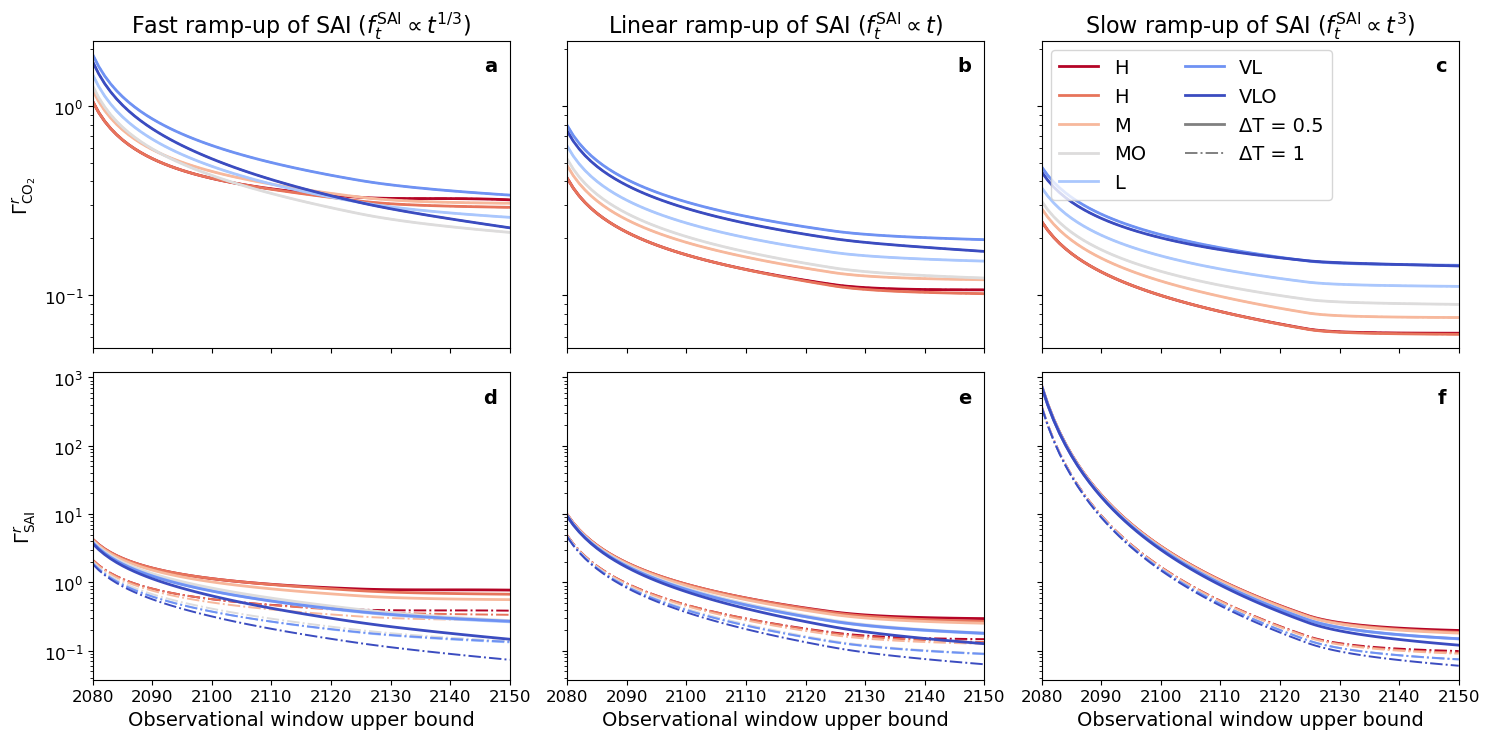

In [ ]:
# Raw SEs only, ΔT = 0.5 only, unshared y-axes
fig, ax = gp.plot_se_grid(df, rows=gp.DEFAULT_ROWS[:2], styles={0.5: "-", 1.0: "-."},
                          sharey='row', figsize=(15, 7.5),
                          xlim=(2080, 2150) if YEAR0 == 2075 else (2030, 2100))
fig.savefig(FIG_DIR / f"gamma_ramps_abbrv_{YEAR0}.png", dpi=350)

## 7. Single-point queries

In [ ]:
# SEs for one scenario, ramp, ΔT and window (here: VLO, z = 1, ΔT = 0.5, window 2026-2100)
c = gm.concentration_ratio(scen["verylow-overshoot"], N=75)
r = gm.gamma_standard_errors(c, z=1.0, delta_T=0.5, sigma=SIGMA, **DESIGN)
r.se_co2, r.se_sai, r.corr

In [ ]:
# Export the table
df.to_csv(FIG_DIR / "gamma_ramps_se_table.csv", index=False)

# Other options

<string>:63: UserWarning: Data has no positive values, and therefore cannot be log-scaled.


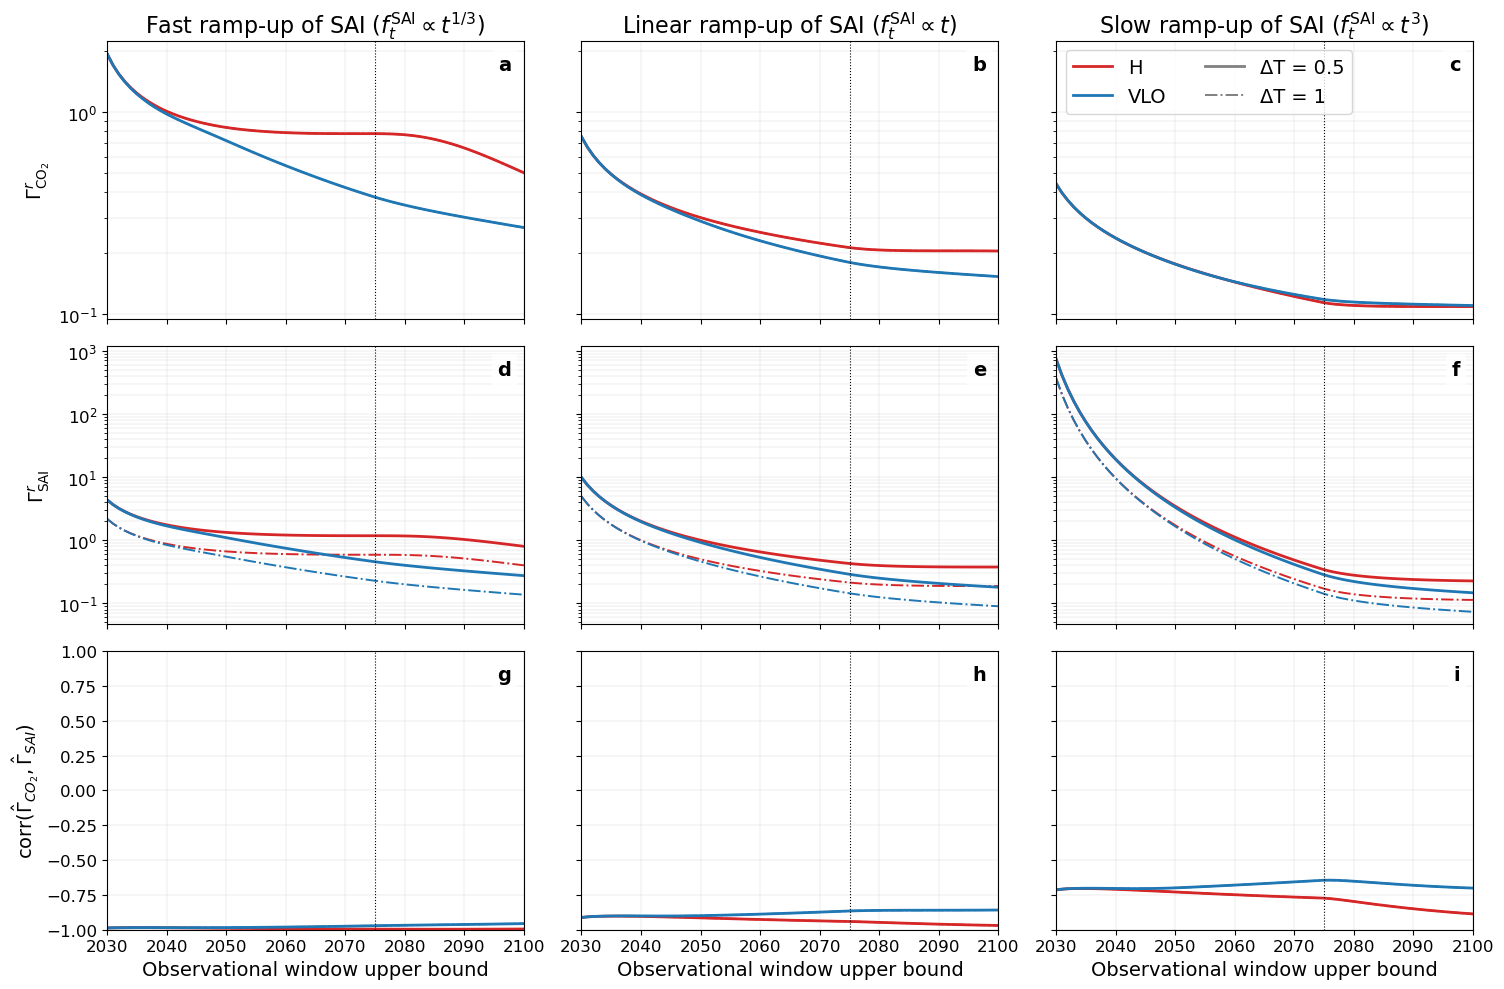

In [ ]:
# A subset of scenarios with custom colors, and the CO2-SAI estimate correlation as an extra row
rows = gp.DEFAULT_ROWS[:2] + [("corr", r"corr($\hat\Gamma_{CO_2}, \hat\Gamma_{SAI}$)")]
fig, ax = gp.plot_se_grid(df, rows=rows, hue_order=["high-extension / high-overshoot", "verylow-overshoot"],
                          colors=["tab:red", "tab:blue"], figsize=(15, 10))
for a in ax[2]:
    a.set_yscale("linear"); a.set_ylim(-1, 1)